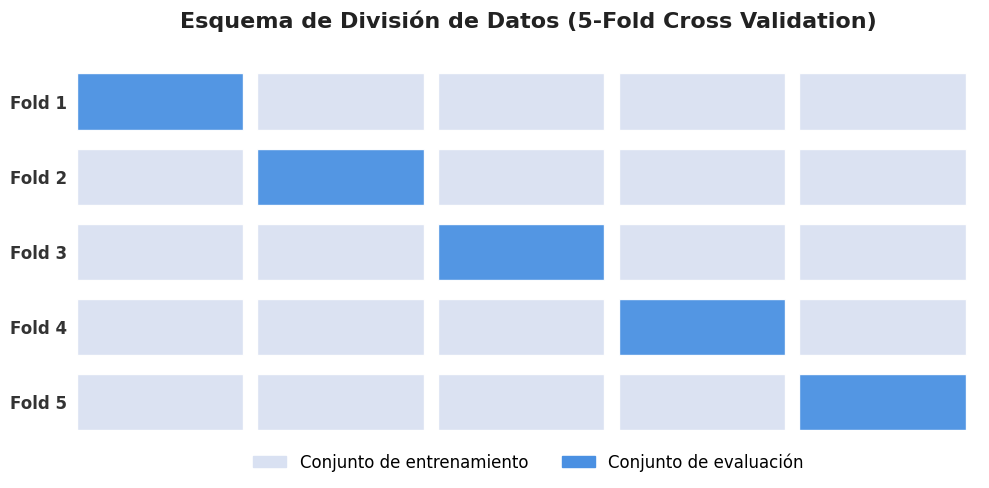

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches

# =========================================================
# Configuración del Esquema K-Fold
# =========================================================
K = 5

# Colores (Puedes cambiarlos a tu gusto)
color_train = '#D9E1F2'  # Azul claro/grisáceo para el Entrenamiento
color_test = '#4A90E2'   # Azul vibrante para la Evaluación

# Crear figura y lienzo
fig, ax = plt.subplots(figsize=(10, 5))

# =========================================================
# Dibujar los bloques de datos
# =========================================================
# Recorremos cada Fold (filas) y cada fracción del dataset (columnas)
for fold in range(K):
    for chunk in range(K):
        
        # Lógica del K-Fold: Si el fragmento coincide con el fold actual, es evaluación.
        if fold == chunk:
            color = color_test
        else:
            color = color_train
        
        # Calcular posición Y invertida para que "Fold 1" quede arriba
        y_pos = K - fold - 1
        
        # Dibujar el rectángulo (x, y, ancho, alto)
        rect = plt.Rectangle((chunk, y_pos), 0.92, 0.75, color=color, alpha=0.95, ec='white')
        ax.add_patch(rect)

# =========================================================
# Configuración visual de ejes y etiquetas
# =========================================================
ax.set_xlim(0, K)
ax.set_ylim(0, K)

# Etiquetas del Eje Y (Fold 1, Fold 2...)
ax.set_yticks(np.arange(K) + 0.375) # Centrado vertical de los textos
# Generamos la lista invertida para que coincida con la posición visual
etiquetas_y = [f'Fold {K - i}' for i in range(K)] 
ax.set_yticklabels(etiquetas_y, fontsize=12, fontweight='bold', color='#333333')

# Ocultar Eje X (ya que representa la totalidad de los datos conceptualmente) y líneas de borde
ax.set_xticks([])
ax.tick_params(left=False)
for spine in ax.spines.values():
    spine.set_visible(False)

# =========================================================
# Agregar Leyenda y Título
# =========================================================
train_patch = mpatches.Patch(color=color_train, label='Conjunto de entrenamiento')
test_patch = mpatches.Patch(color=color_test, label='Conjunto de evaluación')

# Ubicar la leyenda en la parte inferior del gráfico
ax.legend(handles=[train_patch, test_patch], loc='lower center', 
          bbox_to_anchor=(0.5, -0.15), ncol=2, fontsize=12, frameon=False)

plt.title('Esquema de División de Datos (5-Fold Cross Validation)', 
          fontsize=16, fontweight='bold', pad=20, color='#222222')

plt.tight_layout()
plt.show()